# Ex.No-12 Face Detection with Haar Cascades
# Name:Vignesh P
# Reg.No: 212224230302


In [1]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt

In [2]:
model = cv2.imread('image_01.jpeg',0)
withglass = cv2.imread('image_02.jpeg',0)
group = cv2.imread('image_03.jpeg',0)

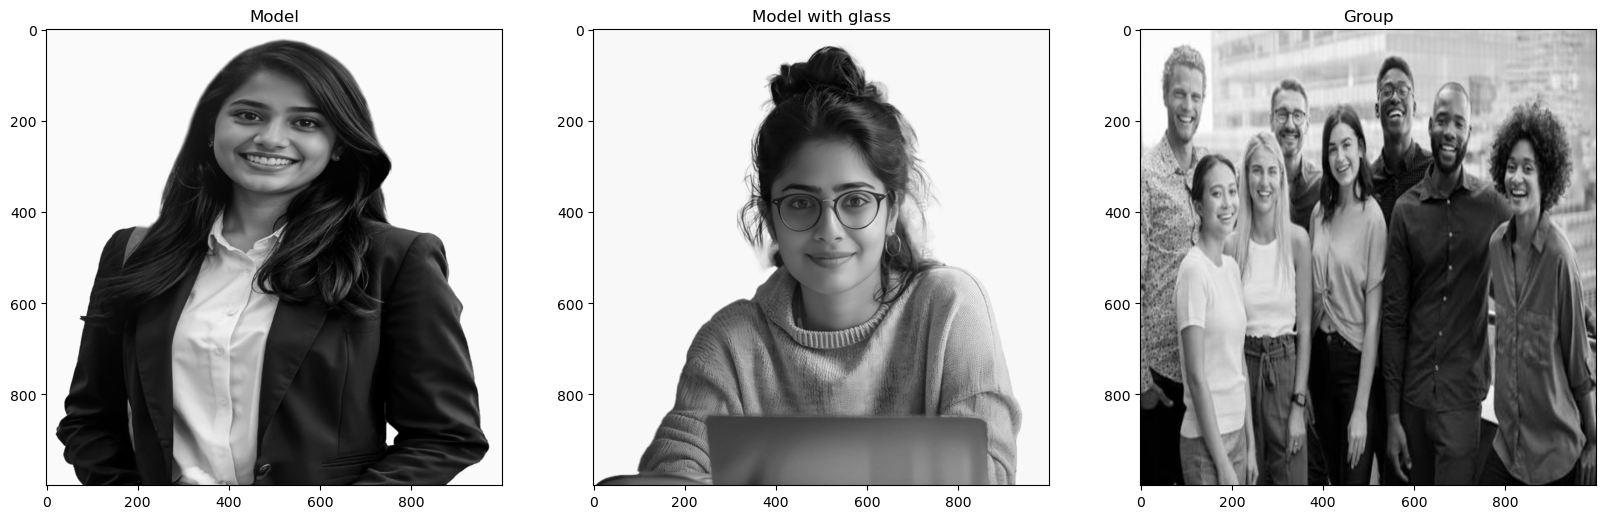

In [3]:
plt.figure(figsize=(20,10))
plt.subplot(131);plt.imshow(cv2.resize(model, (1000, 1000)),cmap='gray');plt.title("Model")
plt.subplot(132);plt.imshow(cv2.resize(withglass, (1000, 1000)),cmap='gray');plt.title("Model with glass")
plt.subplot(133);plt.imshow(cv2.resize(group, (1000, 1000)),cmap='gray');plt.title("Group")
plt.show()

# Cascade Files

In [4]:
face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'

face_cascade = cv2.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    raise RuntimeError(
        f"Face cascade could not be loaded.\nPath: {face_cascade_path}"
    )

print("Face cascade loaded successfully!")
print(face_cascade_path)

Face cascade loaded successfully!
C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\cv2\data\haarcascade_frontalface_default.xml


# Face Detection

In [5]:
def detect_face(img):
    face_img = img.copy()

    # Convert to grayscale if the image is colored
    if len(face_img.shape) == 3:
        gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = face_img

    face_rects = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    for (x, y, w, h) in face_rects:
        cv2.rectangle(
            face_img,
            (x, y),
            (x + w, y + h),
            (255, 255, 255),
            3
        )

    return face_img

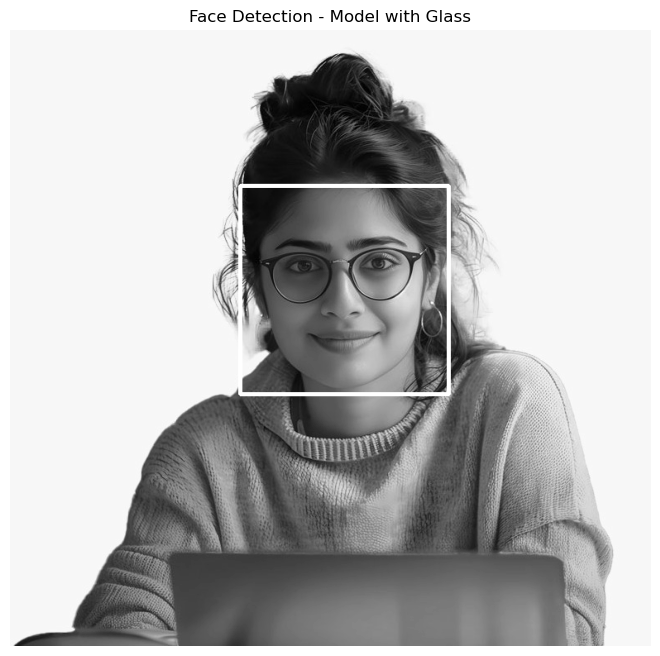

In [6]:
result = detect_face(withglass)

plt.figure(figsize=(10, 8))
plt.imshow(result, cmap='gray')
plt.title("Face Detection - Model with Glass")
plt.axis('off')
plt.show()

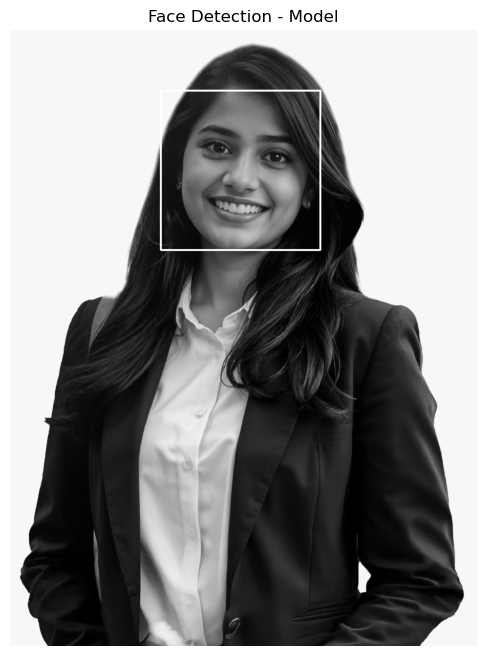

In [7]:
result = detect_face(model)

plt.figure(figsize=(10, 8))
plt.imshow(result, cmap='gray')
plt.title("Face Detection - Model")
plt.axis('off')
plt.show()

In [8]:
eye_cascade_path = cv2.data.haarcascades + 'haarcascade_eye.xml'

eye_cascade = cv2.CascadeClassifier(eye_cascade_path)

if eye_cascade.empty():
    raise RuntimeError(
        f"Eye cascade could not be loaded.\nPath: {eye_cascade_path}"
    )

print("Eye cascade loaded successfully!")
print(eye_cascade_path)

Eye cascade loaded successfully!
C:\Users\admin\AppData\Roaming\Python\Python311\site-packages\cv2\data\haarcascade_eye.xml


In [9]:
def detect_eyes(img):
    face_img = img.copy()

    # Convert to grayscale
    if len(face_img.shape) == 3:
        gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = face_img

    # First detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    # Detect eyes inside each detected face
    for (x, y, w, h) in faces:

        roi_gray = gray[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(15, 15)
        )

        for (ex, ey, ew, eh) in eyes:

            cv2.rectangle(
                face_img,
                (x + ex, y + ey),
                (x + ex + ew, y + ey + eh),
                (255, 255, 255),
                2
            )

    return face_img

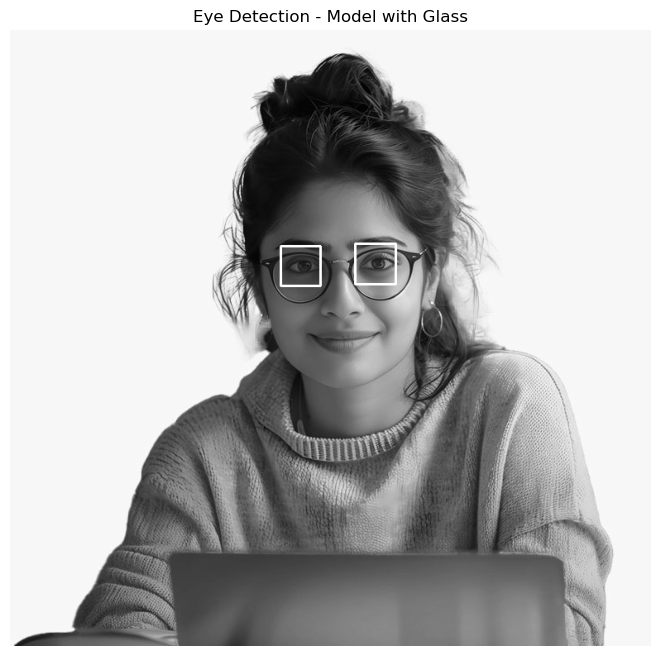

In [10]:
result = detect_eyes(withglass)

plt.figure(figsize=(10, 8))
plt.imshow(result, cmap='gray')
plt.title("Eye Detection - Model with Glass")
plt.axis('off')
plt.show()

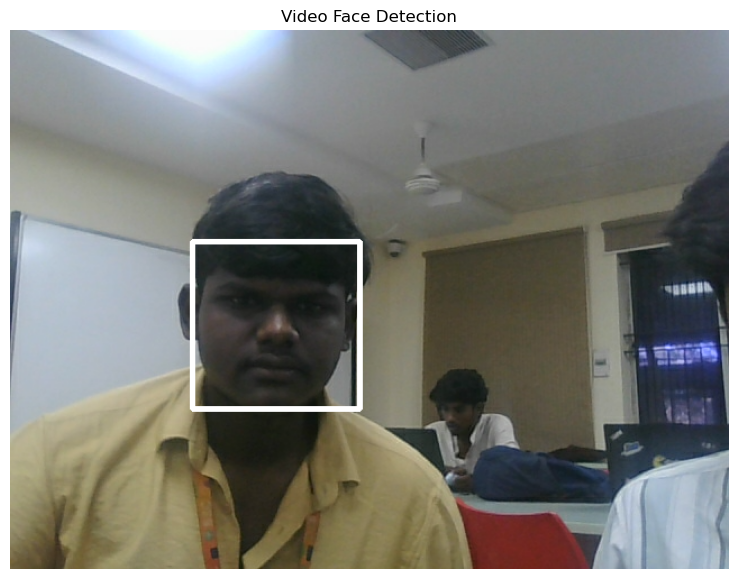

In [12]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError(
        "Could not open the camera. "
        "Check whether your webcam is connected or being used by another application."
    )

plt.ion()

fig, ax = plt.subplots(figsize=(10, 7))

ret, frame = cap.read()

if not ret:
    cap.release()
    plt.close(fig)
    raise RuntimeError("Could not read the first frame from the camera.")

frame = detect_face(frame)

im = ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax.set_title("Video Face Detection")
ax.axis('off')

while plt.fignum_exists(fig.number):

    ret, frame = cap.read()

    if not ret:
        print("Could not read frame from camera.")
        break

    frame = detect_face(frame)

    im.set_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    plt.pause(0.01)

cap.release()
plt.ioff()
plt.close(fig)